# 8.1. Stabla odlučivanja

In [ ]:
from sklearn import tree, datasets
from sklearn import model_selection as skms
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# gist 8a
def plot_boundary(ax, data, tgt, model, dims, grid_step = .01):
    twoD = data[:, list(dims)]
    min_x1, min_x2 = np.min(twoD, axis=0) + 2 * grid_step
    max_x1, max_x2 = np.max(twoD, axis=0) - grid_step
    xs, ys = np.mgrid[min_x1:max_x1:grid_step,
                      min_x2:max_x2:grid_step]
    grid_points = np.c_[xs.ravel(), ys.ravel()]
    preds = model.fit(twoD, tgt).predict(grid_points).reshape(xs.shape)
    ax.pcolormesh(xs,ys,preds,cmap=plt.cm.coolwarm)
    ax.set_xlim(min_x1, max_x1)
    ax.set_ylim(min_x2, max_x2)

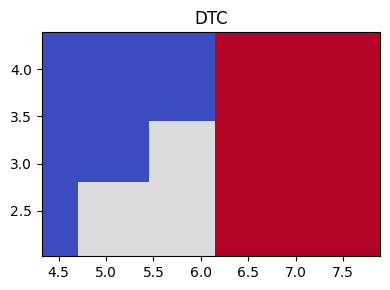

In [ ]:
iris = datasets.load_iris()
tts = skms.train_test_split(iris.data, iris.target, test_size=0.33, random_state=21)
(iris_train_ftrs, iris_test_ftrs, iris_train_tgt, iris_test_tgt) = tts

tree_classifiers = {'DTC': tree.DecisionTreeClassifier(max_depth=3)}
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
for name, mod in tree_classifiers.items():
    plot_boundary(ax, iris.data, iris.target, mod, [0, 1])
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [ ]:
dtc = tree.DecisionTreeClassifier()
scores = skms.cross_val_score(dtc, iris.data, iris.target, cv=3, scoring='accuracy')
print(scores)


[0.98 0.94 0.96]


In [ ]:
useclass = 1
tts_1c = skms.train_test_split(iris.data, iris.target==useclass, test_size=0.33, random_state=21)
(iris_train_ftrs_1c, iris_test_ftrs_1c, iris_train_tgt_1c, iris_test_tgt_1c) = tts_1c

iris_1c_tree = tree.DecisionTreeClassifier(max_depth=3) #max_depth - do koje razine idemo kroz stablo
iris_1c_tree.fit(iris_train_ftrs_1c, iris_train_tgt_1c)

DecisionTreeClassifier(max_depth=3)

In [ ]:
%pip install pydotplus

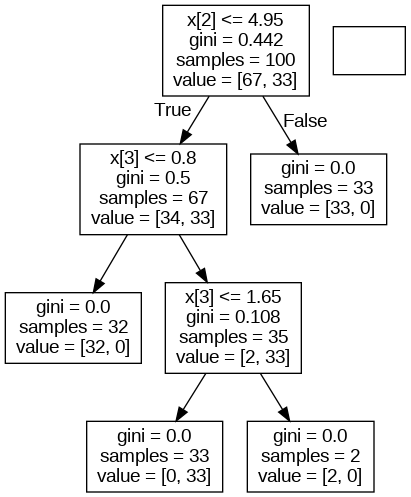

In [ ]:
import pydotplus
from IPython.display import Image

dot_data = tree.export_graphviz(iris_1c_tree, out_file=None)
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png('iris.png')
Image('iris.png', width=500, height=500)

In [ ]:
iris_tree = tree.DecisionTreeClassifier()
iris_tree.fit(iris_train_ftrs, iris_train_tgt)

with open('iris.dot', 'w') as f:
    dot_data = tree.export_graphviz(iris_tree, out_file=f, feature_names=iris.feature_names,
                                    class_names=iris.target_names, filled=True, rounded=True)

In [ ]:
# Terminal naredba (stablo u boji): dot -Tpng iris.dot -o iris.png

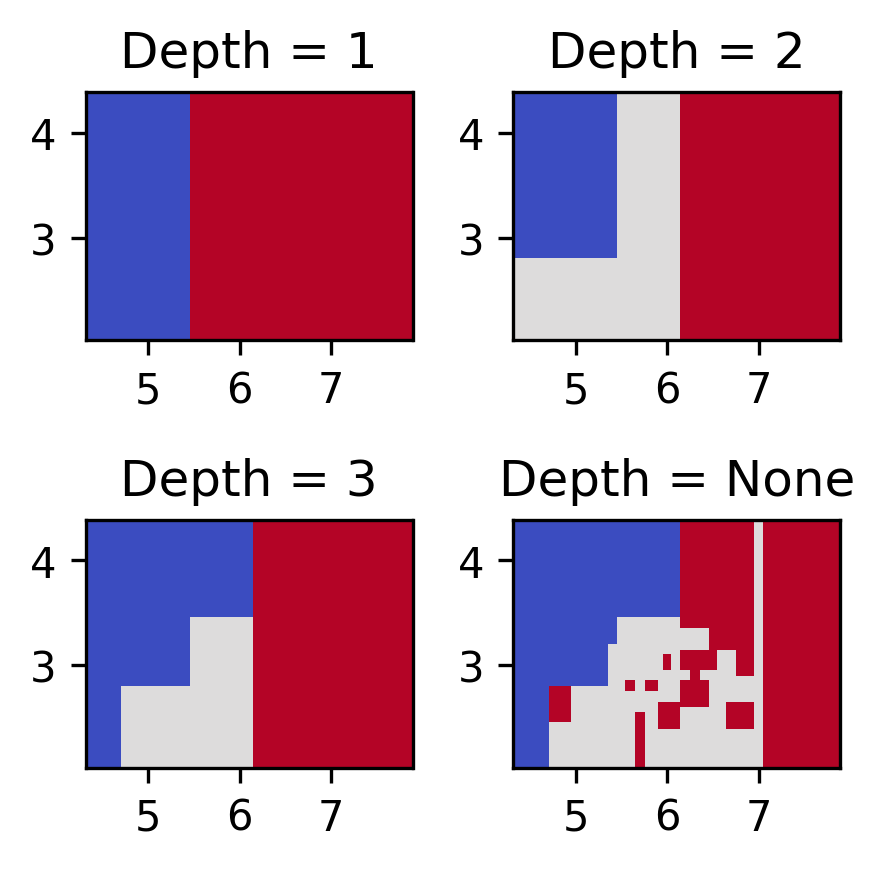

In [ ]:
fig, axes = plt.subplots(nrows = 2,ncols = 2,figsize = (3,3), dpi=300)
depths = [1,2,3, None]

for depth, ax in zip(depths, axes.flat):
  dtc_model = tree.DecisionTreeClassifier(max_depth=depth)
  plot_boundary(ax, iris.data, iris.target, dtc_model, [0,1])
  ax.set_title(f"Depth = {depth}")

plt.tight_layout()
plt.show()

# 8.2. Klasifikator potpornih vektora

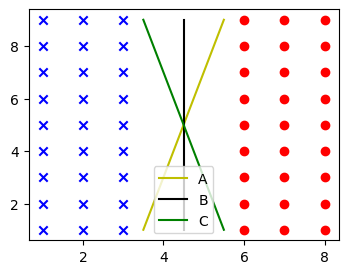

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1,figsize=(4,3))
# fancy way to get cross-product of points
left  = np.mgrid[1:4.0, 1:10].reshape(2, -1).T
right = np.mgrid[6:9.0, 1:10].reshape(2, -1).T
# data points
ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')
# separating lines
ax.plot([3.5, 5.5], [1,9], 'y', label='A')
ax.plot([4.5, 4.5], [1,9], 'k', label='B')
ax.plot([3.5, 5.5], [9,1], 'g', label='C')
ax.legend(loc='lower center')

(0.0, 9.0)

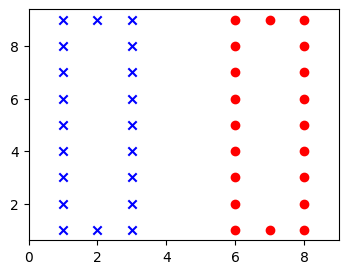

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
# fancy way to get cross-product of points
left  = np.mgrid[1:4:2, 1:10].reshape(2, -1).T
right = np.mgrid[6:9:2, 1:10].reshape(2, -1).T
ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter([2,2], [1,9], c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')
ax.scatter([7,7], [1,9], c='r', marker='o')
ax.set_xlim(0,9)


(0.0, 9.0)

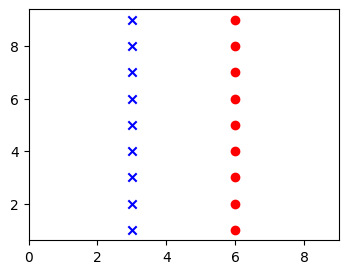

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
left  = np.mgrid[3:4, 1:10].reshape(2, -1).T
right = np.mgrid[6:7, 1:10].reshape(2, -1).T
ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')
ax.set_xlim(0,9)


In [ ]:
# ove točke koje su ostale nazivaju se "potporni vektori". Gledaju na suprostavljene klase

In [ ]:
from sklearn import svm
from sklearn import datasets

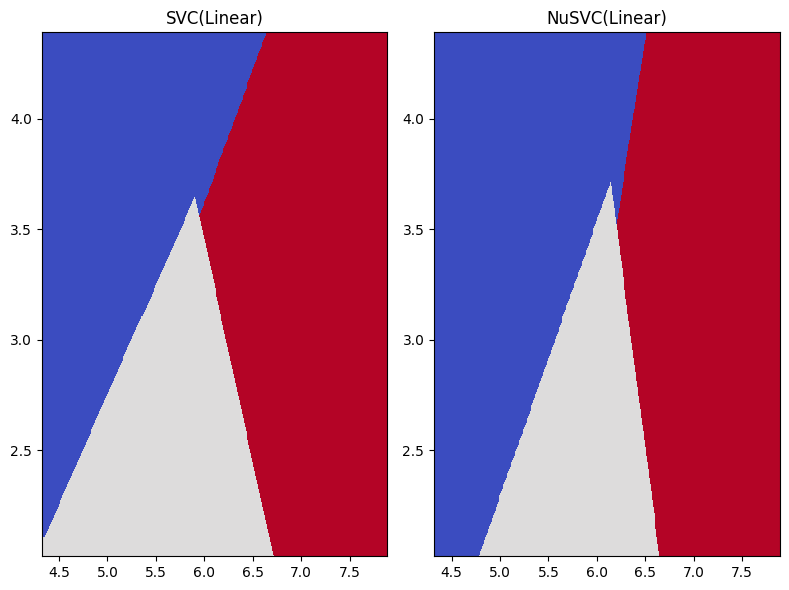

In [ ]:
sv_class = {"SVC(Linear)": svm.SVC(kernel='linear'), "NuSVC(Linear)": svm.NuSVC(kernel='linear', nu=.9)}
iris = datasets.load_iris()

fig, axes = plt.subplots(1,2,figsize=(8,6))
for (name, mod), ax in zip(sv_class.items(), axes.flat):
    plot_boundary(ax, iris.data, iris.target, mod, (0,1))
    #ax.scatter(iris.data[:,0], iris.data[:,1], c=iris.target
    ax.set_title(name)
plt.tight_layout()

# 8.2.1. Parametri za SVC

In [ ]:
# Gist 8b

#za gist server - SVC funkcije
def do_linear_svc_separators(svc_maker, pname, params, ax):
    xys = (np.linspace(2,8,100),
           np.linspace(2,8,100))

    for p in params:
        kwargs = {pname:p, 'kernel':'linear'}
        svc = svc_maker(**kwargs).fit(ftrs, tgt)
        # plot_separator is in mlwpy.py
        plot_separator(svc, *xys,
                       '{}={:g}'.format(pname, p), ax=ax)


def plot_separator(model, xs, ys, label='', ax=None):
    if ax is None:
        ax = plt.gca()

    xy = np_cartesian_product(xs, ys)
    z_shape = (xs.size, ys.size) # verus shape[0]?
    zs = model.decision_function(xy).reshape(z_shape)

    contours = ax.contour(xs, ys, zs,
                          colors='k', levels=[0],
                          linestyles=['-'])
    fmt = {contours.levels[0] : label}
    labels = ax.clabel(contours, fmt=fmt, inline_spacing=10)
    [l.set_rotation(-90) for l in labels]

def np_cartesian_product(*arrays):
  ndim = len(arrays)
  return np.stack(np.meshgrid(*arrays), axis=-1).reshape(-1, ndim)

Text(0.5, 1.0, '$\\nu$ Boundaries')

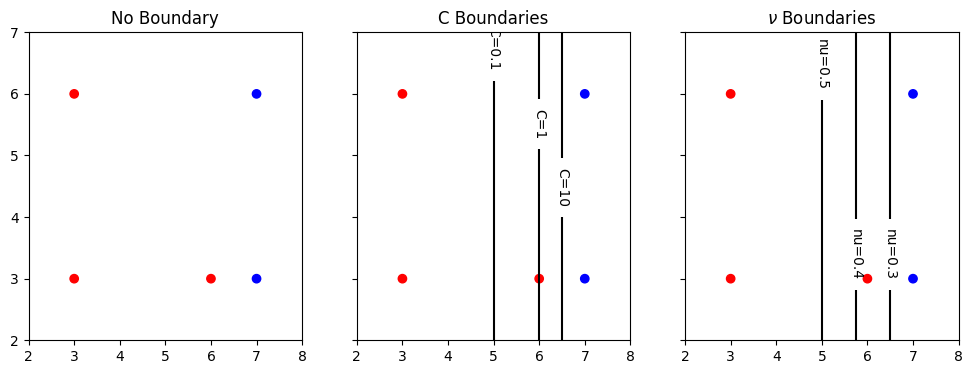

In [ ]:
ftrs = np.array([[3,3],
                 [3,6],
                 [7,3],
                 [7,6],
                 [6,3]])
tgt  = np.array([0,0,1,1,0])
colors = np.array(['r', 'b'])
Cs = [.1, 1.0, 10]
nus = [.3, .4, .5]
fig, axes = plt.subplots(1,3,figsize=(12,4),
                         sharex=True, sharey=True)
for ax in axes:
    ax.scatter(ftrs[:,0], ftrs[:,1], c=colors[tgt])
ax.set_xlim(2,8); ax.set_ylim(2,7)
do_linear_svc_separators(svm.SVC,   "C",   Cs, axes[1])
do_linear_svc_separators(svm.NuSVC, "nu", nus, axes[2])
axes[0].set_title("No Boundary")
axes[1].set_title("C Boundaries")
axes[2].set_title(r"$\nu$ Boundaries")

(np.float64(-2.4437571776898643),
 np.float64(3.7366171479413057),
 np.float64(-4.534257828935317),
 np.float64(4.076938253465614))

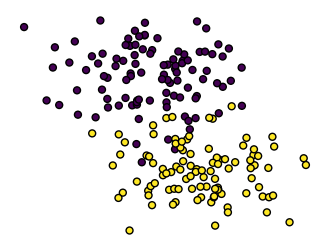

In [ ]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt


ftrs, tgt = datasets.make_blobs(centers=2,
                                n_features=3,
                                n_samples=200,
                                center_box = (-2.0, 2.0),
                                random_state=20)
# note, using three features, but graphing only two dimensions
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.scatter(ftrs[:, 0], ftrs[:, 1],
           marker='o', c=tgt, s=25, edgecolor='k')
ax.axis('off')

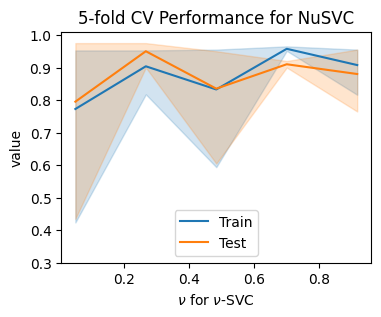

In [ ]:
import sklearn.model_selection as skms
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
nus = np.linspace(0.05, 2.0, 10)
tt = skms.validation_curve(svm.NuSVC(kernel='linear'),
                           ftrs, tgt,
                           param_name='nu',
                           param_range=nus,
                           cv=5)
train_scores, test_scores = tt
train_df = pd.DataFrame(train_scores).stack().reset_index()
train_df.columns = ['fold', 'nu_index', 'value']
train_df['nu'] = train_df['nu_index'].apply(lambda x: nus[x])
train_df = train_df.drop('nu_index', axis=1)
train_df['variable'] = 'Train'

test_df = pd.DataFrame(test_scores).stack().reset_index()
test_df.columns = ['fold', 'nu_index', 'value']
test_df['nu'] = test_df['nu_index'].apply(lambda x: nus[x])
test_df = test_df.drop('nu_index', axis=1)
test_df['variable'] = 'Test'
tt_df = pd.concat([train_df, test_df])
fig,ax = plt.subplots(1,1,figsize=(4,3))
ax = sns.lineplot(data=tt_df,
                  x='nu',
                  y='value',
                  hue='variable')

ax.set_title('5-fold CV Performance for NuSVC')
ax.set_xlabel("\n".join([r'$\nu$ for $\nu$-SVC']))
ax.set_ylim(.3, 1.01)
ax.legend(loc='lower center')